# Summary

This local-window AR-MLP is an intentionally restricted model.

1. Create train/test datasets consisting solely of 16-bit even-parity bitstrings.
2. Train a local-window AR-MLP.
3. Generate 5,000 bitstrings using the trained model.
4. Calculate the odd parity rate, global parity expectation, and KL divergence for the generated samples.

Key limitation:

```text
When predicting x_i, the model does not look at the entire prefix;
it only considers the immediately preceding 'window_size' bits.
```

Consequently, it is difficult for this model to learn the global parity constraint.

In [1]:
# Imports and reproducibility
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import itertools

seed_val = 2
np.random.seed(seed_val)
torch.manual_seed(seed_val)

In [2]:
# Experiment setting

n_bits = 16

# Main setting used in the experiment
n_train = 16384 # 2000, 4096, 8192, 16384 - no ablation
n_test = 4096 # 2000, 4096, 4096, 4096 - no ablation

# local-window size: When predicting x_i, look only the preceding window_size bits
window_size = 12 # 4, 8, 12

hidden_dim = 64
epochs = 200 # The trend was clearly visible by just 200 epochs;
             # while 1,000 epochs can be used for verification, there is hardly any significant change.
batch_size = 128
lr = 1e-3

## Generate all even-parity bitstrings
There are `2^16 = 65,536` possible 16-bit bitstrings in total.  
Of these, half—`2^15 = 32,768`—have even parity.

In [3]:
# Generate all even-parity bitstrings

# Generate all possible combinations of 0s and 1s with a length of 16 bits.
combinations = list(itertools.product([0, 1], repeat=n_bits))
all_bitstrings = np.array(combinations, dtype=np.float32)

# Calculating the parity of each bitstring
parity = all_bitstrings.sum(axis=1) % 2
even_bitstrings = all_bitstrings[parity == 0] # boolean indexing for filtering

## Create train/test data

The train and test sets are split within the even parity space without any duplicates.

This ensures:

- No duplicates within `X_train`
- No duplicates within `X_test`
- No overlap between `X_train` and `X_test`
- Both contain only even parity data

In [4]:
# Create unique and disjoint train/test data

# Permute the indices of even_x.
idx = np.random.permutation(len(even_bitstrings))

train_idx = idx[:n_train]
test_idx = idx[n_train:n_train + n_test]

X_train = even_bitstrings[train_idx]
X_test = even_bitstrings[test_idx]

## Convert data to PyTorch tensors

A GPU is not used. This experiment can be sufficiently performed using a CPU.

In [5]:
# Convert data to torch tensors
# Since the autoregressive MLP model extends PyTorch's `nn.Module`, the input data must be a Torch tensor.

# Convert a NumPy array to a torch tensor.
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)

## Definition of the AR-MLP model

The model input is a masked bitstring of length `n_bits`.  
The model output consists of logits for each bit position.

```text
logits[:, i] = the preceding value before the prob. of i-th bit is 1
sigmoid(logits[:, i]) = p(x_i = 1 | local context)
```

In [6]:
# Define AR-MLP model
class AutoregressiveMLP(nn.Module):
    def __init__(self, n_bits=16, hidden_dim=64):
        super().__init__()
        self.n_bits = n_bits

        self.net = nn.Sequential(
            nn.Linear(n_bits, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, n_bits)
        )

    def forward(self, x):
        return self.net(x) # return: logits


model = AutoregressiveMLP(
    n_bits=n_bits,
    hidden_dim=hidden_dim
)

optimizer = torch.optim.Adam(model.parameters(), lr=lr)

print(model)

AutoregressiveMLP(
  (net): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=16, bias=True)
  )
)


## example
Below is an example illustrating how local-window masking actually works.

For instance, if `i=10` and `window_size=4`,  
when predicting the 10th position, only indices `6, 7, 8, and 9` are retained, while the others are masked to zero.

In [7]:
# Local-window masking example

example_x = X_train_t[:2]
i = 10

local_input_example = torch.zeros_like(example_x)

start = max(0, i - window_size)

if i > 0:
    local_input_example[:, start:i] = example_x[:, start:i]

print("Original example:")
print(example_x.numpy().astype(int))

print("\nLocal-window input for predicting bit index", i)
print(local_input_example.numpy().astype(int))

print("\nThe model will use columns", list(range(start, i)), "to predict column", i)

Original example:
[[0 0 1 0 0 0 0 1 0 0 1 0 1 0 0 0]
 [0 0 0 0 0 0 1 1 0 0 0 1 1 0 0 0]]

Local-window input for predicting bit index 10
[[0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0]]

The model will use columns [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] to predict column 10


## Training loop
Here, instead of creating a separate loss function, the NLL is calculated directly within the training loop.

For each batch:

1. Iterate from `i = 0` to `15`.
2. Generate a local-window input to predict the `i`-th bit.
3. Feed the input into the model to compute logits.
4. Compare `logits[:, i]` with the actual `batch[:, i]` using BCE.
5. Sum the losses for each bit to obtain the NLL for a single sample.

In [8]:
# history placeholder
history = {
    "train_nll": [],
    "test_nll": []
}


In [9]:
# training loop
for epoch in range(epochs):

    model.train()

    # permute train data in each epoch
    perm = torch.randperm(len(X_train_t))
    total_train_loss = 0.0

    # mini-batch training
    for start_batch in range(0, len(X_train_t), batch_size):
        batch_idx = perm[start_batch:start_batch + batch_size]
        batch = X_train_t[batch_idx]

        batch_size_current, n_bits_current = batch.shape # (batch, 16)

        # Tensor to accumulate NLL per sample
        total_loss_per_sample = torch.zeros(batch_size_current)

        # Predict each bit position one by one
        for i in range(n_bits_current):

            # creating local-window input
            local_input = torch.zeros_like(batch)

            start = max(0, i - window_size)

            if i > 0:
                local_input[:, start:i] = batch[:, start:i]

            # model forward
            logits = model(local_input) # (128, 16)

            # Use only the logit and target for the i-th bit.
            bit_logits = logits[:, i] # 128
            bit_target = batch[:, i] # 128

            # BCE per bit = -log p_theta(x_i | local context)
            bit_loss = F.binary_cross_entropy_with_logits(
                bit_logits,
                bit_target,
                reduction="none"
            ) # 128

            # accumulating BCE loss at each bit position (from the 0th to the 15th bit)
            # while completing a single 16-bit string.
            total_loss_per_sample += bit_loss

        # Avg. loss value for each batch
        loss = total_loss_per_sample.mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # total train loss
        total_train_loss += loss.item() * len(batch)

    train_nll = total_train_loss / len(X_train_t)
    history["train_nll"].append(train_nll)

    # Test NLL
    model.eval()

    with torch.no_grad():
        batch = X_test_t
        batch_size_current, n_bits_current = batch.shape
        total_loss_per_sample = torch.zeros(batch_size_current)

        for i in range(n_bits_current):
            local_input = torch.zeros_like(batch)

            start = max(0, i - window_size)

            if i > 0:
                local_input[:, start:i] = batch[:, start:i]

            logits = model(local_input)

            bit_logits = logits[:, i]
            bit_target = batch[:, i]

            bit_loss = F.binary_cross_entropy_with_logits(
                bit_logits,
                bit_target,
                reduction="none"
            )

            total_loss_per_sample += bit_loss

        test_nll = total_loss_per_sample.mean().item()
        history["test_nll"].append(test_nll)

    if (epoch + 1) % 20 == 0:
        print(
            f"Epoch {epoch+1:4d} | "
            f"Train NLL: {train_nll:.4f} | "
            f"Test NLL: {test_nll:.4f}"
        )

Epoch   20 | Train NLL: 11.0815 | Test NLL: 11.1114
Epoch   40 | Train NLL: 11.0682 | Test NLL: 11.1479
Epoch   60 | Train NLL: 11.0556 | Test NLL: 11.1795
Epoch   80 | Train NLL: 11.0455 | Test NLL: 11.2143
Epoch  100 | Train NLL: 11.0362 | Test NLL: 11.2411
Epoch  120 | Train NLL: 11.0290 | Test NLL: 11.2619
Epoch  140 | Train NLL: 11.0238 | Test NLL: 11.2860
Epoch  160 | Train NLL: 11.0182 | Test NLL: 11.3098
Epoch  180 | Train NLL: 11.0126 | Test NLL: 11.3202
Epoch  200 | Train NLL: 11.0102 | Test NLL: 11.3392


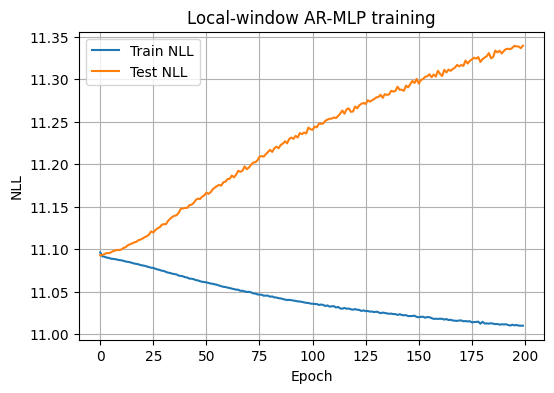

In [10]:
# Plotting NLL history
plt.figure(figsize=(6, 4))
plt.plot(history["train_nll"], label="Train NLL")
plt.plot(history["test_nll"], label="Test NLL")
plt.xlabel("Epoch")
plt.ylabel("NLL")
plt.title("Local-window AR-MLP training")
plt.legend()
plt.grid(True)
plt.show()

## Generating samples from the trained model

After training, the model directly generates bitstrings.

Generation process:

1. Initialize empty samples where all bits are 0.
2. Generate bits sequentially from `x_1` to `x_16`.
3. At each position, use only the preceding `window_size` bits.
4. Perform sampling using `sigmoid(logit)` as the probability. (using `bernoulli` function)

In [11]:
# Generate samples from trained local-window AR-MLP

model.eval()

n_generated = 5000

with torch.no_grad():
    generated_t = torch.zeros(n_generated, n_bits)

    for i in range(n_bits):

        local_input = torch.zeros_like(generated_t)

        start = max(0, i - window_size)

        if i > 0:
            local_input[:, start:i] = generated_t[:, start:i]

        logits = model(local_input)

        probs = torch.sigmoid(logits[:, i])

        generated_t[:, i] = torch.bernoulli(probs)

generated_local = generated_t.numpy().astype(np.int8)

print("Generated samples:", generated_local.shape)
print("First 10 generated samples:")
print(generated_local[:10])

Generated samples: (5000, 16)
First 10 generated samples:
[[1 0 0 0 0 0 0 0 1 0 0 1 1 0 1 1]
 [1 0 0 0 0 1 0 1 0 1 0 1 1 1 1 1]
 [1 1 1 1 0 0 0 0 1 0 0 0 1 1 1 1]
 [0 1 0 0 1 1 1 0 0 0 0 1 1 1 0 1]
 [1 0 0 0 1 0 1 1 1 1 0 0 0 1 0 0]
 [0 1 1 0 0 0 0 1 1 1 1 1 1 1 0 0]
 [0 0 0 0 1 1 0 1 1 0 1 1 1 1 1 0]
 [1 0 1 0 0 0 1 1 0 1 1 1 0 0 0 0]
 [0 0 0 0 1 0 1 0 0 0 1 1 1 0 1 1]
 [1 0 1 1 0 1 1 0 0 0 0 1 0 0 0 0]]


## Evaluation of generated samples

Key evaluation metrics:

- **Odd parity violation rate**
  - 0 for an ideal even-parity model
  - Approximately 0.5 for a 50/50 mix of even and odd parity

- **Global parity expectation**
  - +1 for even parity
  - -1 for odd parity
  - Approximately 0 for a 50/50 mix

In [12]:
# Evaluate generated samples

generated_parity = generated_local.sum(axis=1) % 2

odd_rate = generated_parity.mean()
parity_expectation = (1 - 2 * generated_parity).mean()

unique_generated = len(np.unique(generated_local, axis=0))

print("Window size:", window_size)
print("Generated samples:", len(generated_local))
print("Unique generated samples:", unique_generated)
print("Odd parity violation rate:", odd_rate)
print("Global parity expectation:", parity_expectation)

print("\nParity of first 10 generated samples:")
print(generated_parity[:10])

Window size: 12
Generated samples: 5000
Unique generated samples: 4771
Odd parity violation rate: 0.503
Global parity expectation: -0.006

Parity of first 10 generated samples:
[0 1 1 0 1 1 1 1 1 0]


## Check overlaps
While this is not a core metric, it measures the proportion of generated unique samples that overlap with the training set.

Note: If `n_train=16384`, the training set accounts for half of the total 32,768 samples in the even parity support.  
Therefore, even a good model may naturally produce a significant number of samples that overlap with the training set.

In [13]:
# Train/generated overlap diagnostic

gen_set = {tuple(x.astype(int)) for x in generated_local}
train_set = {tuple(x.astype(int)) for x in X_train.astype(int)}

overlap = gen_set.intersection(train_set)

memorization_rate = len(overlap) / len(gen_set) if len(gen_set) > 0 else 0.0

train_coverage = len(X_train) / len(even_bitstrings)

print("Train coverage in even support:", train_coverage)
print("Generated/train overlap rate:", memorization_rate)

Train coverage in even support: 0.5
Generated/train overlap rate: 0.292181932508908


## KL evaluation

In the 16-bit case, there are 32,768 even-parity bitstrings,  
so the exact KL divergence can be calculated by utilizing the entire even-parity space.

```text
D_KL(p_even || p_theta)
```

Here, `p_even` represents the uniform distribution over the even-parity space.

In [14]:
# KL evaluation

model.eval()

even_x = torch.tensor(even_bitstrings.astype(np.float32), dtype=torch.float32)

all_log_probs = []
kl_batch_size = 4096

with torch.no_grad():
    for start_batch in range(0, len(even_x), kl_batch_size):
        batch = even_x[start_batch:start_batch + kl_batch_size]

        batch_size_current, n_bits_current = batch.shape

        log_prob = torch.zeros(batch_size_current)

        for i in range(n_bits_current):

            local_input = torch.zeros_like(batch)

            start = max(0, i - window_size)

            if i > 0:
                local_input[:, start:i] = batch[:, start:i]

            logits = model(local_input)

            bit_logits = logits[:, i]
            bit_target = batch[:, i]

            # log p(x_i = 1 | context)
            log_prob_1 = F.logsigmoid(bit_logits)

            # log p(x_i = 0 | context)
            log_prob_0 = F.logsigmoid(-bit_logits)

            # If the actual bit is 1, use log_prob_1; if it is 0, use log_prob_0.
            bit_log_prob = (
                bit_target * log_prob_1
                + (1 - bit_target) * log_prob_0
            )

            log_prob += bit_log_prob

        all_log_probs.append(log_prob.cpu())

log_p_model_even = torch.cat(all_log_probs).numpy()

log_p_true = -np.log(2 ** (n_bits - 1))

kl_local = np.mean(log_p_true - log_p_model_even)

print("Exact KL D_KL(p_even || p_model):", kl_local)
print("log 2:", np.log(2))

Exact KL D_KL(p_even || p_model): 0.7735001111767303
log 2: 0.6931471805599453


In [15]:
# Final result summary and JSON export

import json

result_summary = {
    "model": "Local-window AR-MLP",
    "objective": "NLL",
    "n_bits": int(n_bits),
    "n_train": int(n_train),
    "n_test": int(n_test),
    "window_size": int(window_size),
    "hidden_dim": int(hidden_dim),
    "epochs": int(epochs),
    "batch_size": int(batch_size),
    "learning_rate": float(lr),
    "generated_samples": int(len(generated_local)),
    "unique_generated_samples": int(len(np.unique(generated_local, axis=0))),
    "odd_rate": float(odd_rate),
    "parity_expectation": float(parity_expectation),
    "kl": float(kl_local)
}

print(result_summary)

file_name = f"ar_mlp_seed{seed_val}_window_size{window_size}_result.json"

with open(file_name, "w") as f:
    json.dump(result_summary, f, indent=4)

print("Saved:", file_name)

{'model': 'Local-window AR-MLP', 'objective': 'NLL', 'n_bits': 16, 'n_train': 16384, 'n_test': 4096, 'window_size': 12, 'hidden_dim': 64, 'epochs': 200, 'batch_size': 128, 'learning_rate': 0.001, 'generated_samples': 5000, 'unique_generated_samples': 4771, 'odd_rate': 0.503, 'parity_expectation': -0.006, 'kl': 0.7735001111767303}
Saved: ar_mlp_seed2_window_size12_result.json
